In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller, coint, grangercausalitytests
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant

from glencore_multi_agent.data import load_glencore, load_commodities

# ── Load data ───────────────────────────────────────────────────────────────
glen = load_glencore()
comms = load_commodities()

# Log prices (levels) — needed for cointegration
glen_logprice = np.log(glen["adj_close"]).rename("glen")

# Align on common dates
comm_cols = ["copper", "brent", "natgas", "gbpusd", "dxy"]
comm_prices = comms[[c for c in comm_cols if c in comms.columns]].ffill()
comm_logprices = np.log(comm_prices).dropna()

# Returns (for VAR and correlation) — stationary
glen_ret = glen["log_return"].rename("glen")
comm_rets = comms[[c for c in comm_cols if f"{c}_log_ret" in comms.columns]]

# Rename return columns cleanly
comm_rets.columns = [c.replace("_log_ret", "") for c in comm_rets.columns]

# Combined returns panel — aligned on GLEN.L trading dates
ret_panel = pd.concat([glen_ret, comm_rets], axis=1).dropna()
price_panel = pd.concat([glen_logprice, comm_logprices], axis=1).dropna()

print(f"Returns panel:  {ret_panel.shape}  cols: {ret_panel.columns.tolist()}")
print(f"Log price panel: {price_panel.shape}  cols: {price_panel.columns.tolist()}")
print(f"Date range: {ret_panel.index[0].date()} → {ret_panel.index[-1].date()}")

  Loading glen_raw from cache: data/raw/glen_raw.csv

Glencore loaded: 3807 rows, 2011-05-20 → 2026-06-19
  Cached to data/raw/copper.csv
  Cached to data/raw/brent.csv
  Cached to data/raw/natgas.csv
  Cached to data/raw/zinc.csv


HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: NI=F"}}}
$NI=F: possibly delisted; no timezone found

1 Failed download:
['NI=F']: possibly delisted; no timezone found


  ✗  nickel (NI=F): No data returned for NI=F. Check ticker or internet connection.
  Cached to data/raw/dxy.csv
  Cached to data/raw/gbpusd.csv

Commodity panel: (3935, 12), 2011-05-19 → 2026-06-23
Returns panel:  (3688, 6)  cols: ['glen', 'copper', 'brent', 'natgas', 'gbpusd', 'dxy']
Log price panel: (3807, 6)  cols: ['glen', 'copper', 'brent', 'natgas', 'gbpusd', 'dxy']
Date range: 2011-05-20 → 2026-06-18


── Return Correlation Matrix ───────────────────────────────
         glen  copper  brent  natgas  gbpusd    dxy
glen    1.000   0.032 -0.005   0.010  -0.029  0.001
copper  0.032   1.000  0.431   0.275  -0.098  0.114
brent  -0.005   0.431  1.000   0.460   0.471 -0.496
natgas  0.010   0.275  0.460   1.000   0.027 -0.008
gbpusd -0.029  -0.098  0.471   0.027   1.000 -0.871
dxy     0.001   0.114 -0.496  -0.008  -0.871  1.000

── Glencore correlations (sorted) ──────────────────────────
copper    0.032
natgas    0.010
dxy       0.001
brent    -0.005
gbpusd   -0.029
Name: glen, dtype: float64


/Users/aryanbhobe/Desktop/Projects/glencore-multi-agent/.venv/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:54: RuntimeWarning: overflow encountered in accumulate
  return bound(*args, **kwds)
/Users/aryanbhobe/Desktop/Projects/glencore-multi-agent/.venv/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:54: RuntimeWarning: overflow encountered in accumulate
  return bound(*args, **kwds)


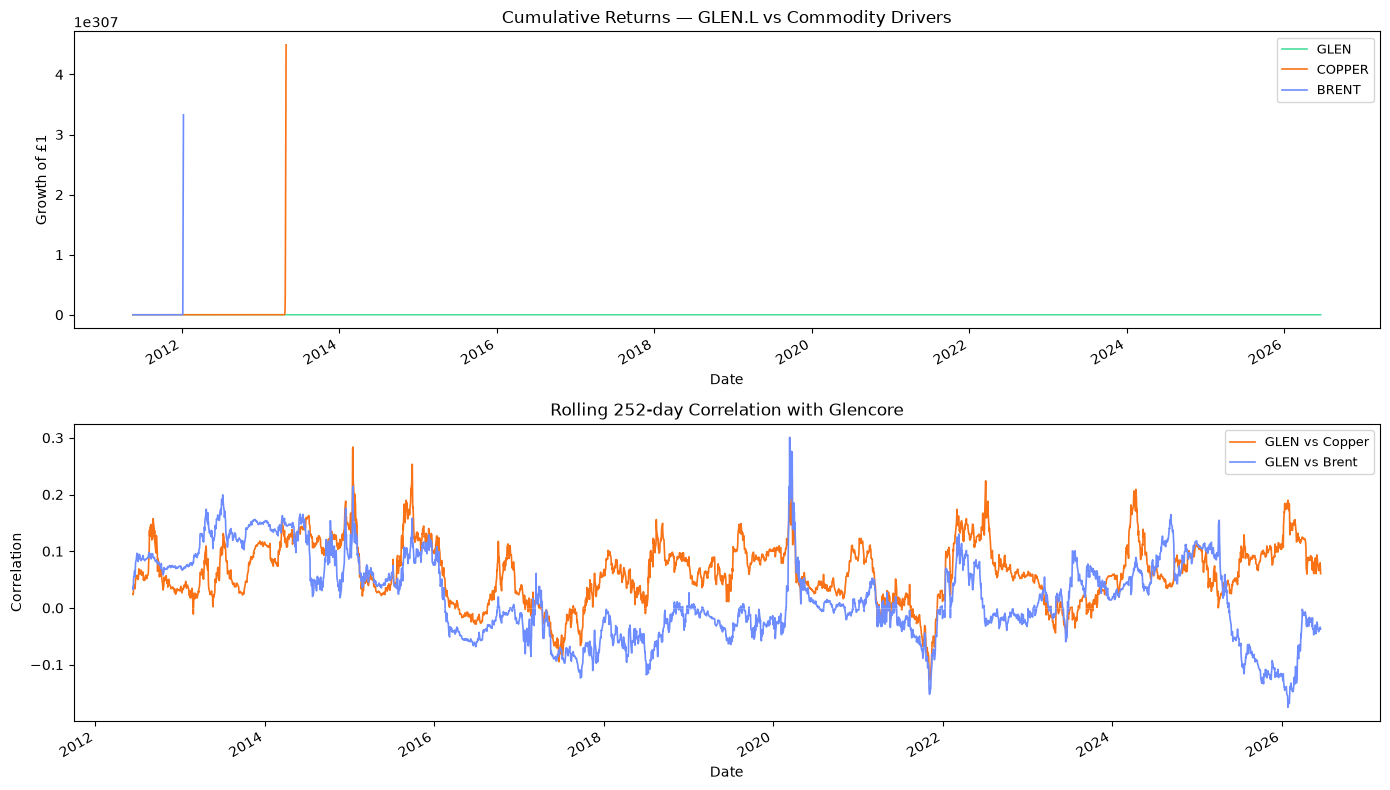

── ADF Tests on Log Price LEVELS (expect: non-stationary = I(1)) ───
Series         ADF Stat    p-value  Stationary?
------------------------------------------------
glen            -2.0482   0.265845     ✗ I(1) ✓
copper          -0.6858   0.850405     ✗ I(1) ✓
brent           -2.5358   0.106998     ✗ I(1) ✓
natgas          -3.5268   0.007324 ⚠ stationary
gbpusd          -2.0314   0.272965     ✗ I(1) ✓
dxy             -2.3280   0.163102     ✗ I(1) ✓

── ADF Tests on Log Returns (expect: stationary = I(0)) ────────────
Series         ADF Stat    p-value  Stationary?
------------------------------------------------
glen           -61.2092   0.000000       ✓ I(0)
copper          -0.0228   0.956604 ⚠ still non-stat
brent           -2.3600   0.153351 ⚠ still non-stat
natgas          -3.3532   0.012663       ✓ I(0)
gbpusd          -2.0134   0.280714 ⚠ still non-stat
dxy             -2.1645   0.219369 ⚠ still non-stat


In [2]:
# ── Static correlation matrix ───────────────────────────────────────────────
corr = ret_panel.corr()
print("── Return Correlation Matrix ───────────────────────────────")
print(corr.round(3).to_string())

print("\n── Glencore correlations (sorted) ──────────────────────────")
print(corr["glen"].drop("glen").sort_values(ascending=False).round(3))

# ── Rolling 252-day correlation with copper ─────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

# Rebased price chart
for col, color in zip(["glen", "copper", "brent"],
                        ["#4ade9e", "#f97316", "#6c8cff"]):
    if col in ret_panel.columns:
        (ret_panel[col] + 1).cumprod().plot(
            ax=ax1, label=col.upper(), color=color, lw=1.2)
ax1.set_title("Cumulative Returns — GLEN.L vs Commodity Drivers")
ax1.set_ylabel("Growth of £1")
ax1.legend(fontsize=9)
ax1.axhline(1, color="white", lw=0.4, alpha=0.3)

# Rolling correlation
if "copper" in ret_panel.columns:
    roll_corr_cu = ret_panel["glen"].rolling(252).corr(ret_panel["copper"])
    roll_corr_cu.plot(ax=ax2, color="#f97316", lw=1.2, label="GLEN vs Copper")
if "brent" in ret_panel.columns:
    roll_corr_br = ret_panel["glen"].rolling(252).corr(ret_panel["brent"])
    roll_corr_br.plot(ax=ax2, color="#6c8cff", lw=1.2, label="GLEN vs Brent")
ax2.axhline(0, color="white", lw=0.5, alpha=0.3)
ax2.set_title("Rolling 252-day Correlation with Glencore")
ax2.set_ylabel("Correlation")
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig("../reports/figures/stage3_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

def adf_summary(series: pd.Series, name: str) -> dict:
    """Run ADF on a series and return a clean summary dict."""
    stat, p, _, _, crit, _ = adfuller(series.dropna(), autolag="AIC")
    return {
        "series": name,
        "adf_stat": round(stat, 4),
        "p_value": round(p, 6),
        "stationary": p < 0.05,
    }

print("── ADF Tests on Log Price LEVELS (expect: non-stationary = I(1)) ───")
print(f"{'Series':<12} {'ADF Stat':>10} {'p-value':>10} {'Stationary?':>12}")
print("-" * 48)
for col in price_panel.columns:
    r = adf_summary(price_panel[col], col)
    flag = "✗ I(1) ✓" if not r["stationary"] else "⚠ stationary"
    print(f"{r['series']:<12} {r['adf_stat']:>10.4f} {r['p_value']:>10.6f} {flag:>12}")

print("\n── ADF Tests on Log Returns (expect: stationary = I(0)) ────────────")
print(f"{'Series':<12} {'ADF Stat':>10} {'p-value':>10} {'Stationary?':>12}")
print("-" * 48)
for col in ret_panel.columns:
    r = adf_summary(ret_panel[col], col)
    flag = "✓ I(0)" if r["stationary"] else "⚠ still non-stat"
    print(f"{r['series']:<12} {r['adf_stat']:>10.4f} {r['p_value']:>10.6f} {flag:>12}")

/Users/aryanbhobe/Desktop/Projects/glencore-multi-agent/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Optimal lag order by criterion:
 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -2.797      -2.787     0.06101      -2.793
1       -27.38      -27.31   1.287e-12      -27.35
2       -27.95     -27.82*   7.271e-13     -27.90*
3      -27.95*      -27.76  7.249e-13*      -27.88
4       -27.94      -27.69   7.307e-13      -27.85
5       -27.94      -27.62   7.368e-13      -27.82
6       -27.93      -27.56   7.415e-13      -27.80
7       -27.93      -27.50   7.380e-13      -27.78
8       -27.93      -27.43   7.439e-13      -27.75
9       -27.92      -27.36   7.513e-13      -27.72
10      -27.91      -27.29   7.544e-13      -27.69
--------------------------------------------------

Using p=3 lags
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Tue, 23, Jun, 2026
Time:                     03:04:38
------------

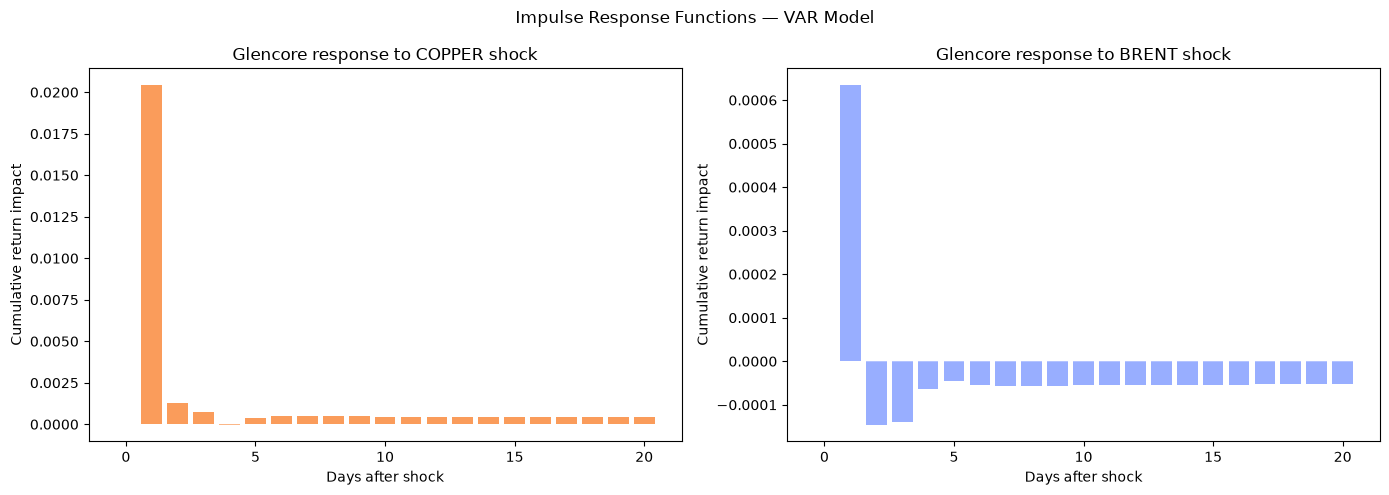

In [3]:
# ── Select lag order ────────────────────────────────────────────────────────
var_model = VAR(ret_panel)
lag_order = var_model.select_order(maxlags=10)
print("Optimal lag order by criterion:")
print(lag_order.summary())

p_opt = lag_order.aic  # use AIC selection; often 1-3 for daily returns
p_opt = max(1, min(p_opt, 5))  # cap at 5 — daily returns rarely need more
print(f"\nUsing p={p_opt} lags")

# ── Fit VAR(p) ───────────────────────────────────────────────────────────────
res_var = var_model.fit(p_opt)
print(res_var.summary())

# ── Impulse Response Functions ───────────────────────────────────────────────
# IRF shows the effect on Glencore of a 1-std shock to each commodity
# over the next N trading days
irf = res_var.irf(periods=20)

# Plot the response of Glencore to copper and brent shocks
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

glen_idx = ret_panel.columns.tolist().index("glen")

for ax, shock_series, color in [
    (axes[0], "copper", "#f97316"),
    (axes[1], "brent", "#6c8cff"),
]:
    if shock_series not in ret_panel.columns:
        continue
    shock_idx = ret_panel.columns.tolist().index(shock_series)
    irf_vals = irf.irfs[:, glen_idx, shock_idx]
    ax.bar(range(len(irf_vals)), irf_vals, color=color, alpha=0.7)
    ax.axhline(0, color="white", lw=0.5, alpha=0.4)
    ax.set_title(f"Glencore response to {shock_series.upper()} shock")
    ax.set_xlabel("Days after shock")
    ax.set_ylabel("Cumulative return impact")

plt.suptitle("Impulse Response Functions — VAR Model", fontsize=12)
plt.tight_layout()
plt.savefig("../reports/figures/stage3_irf.png", dpi=150, bbox_inches="tight")
plt.show()

In [5]:
def granger_test(data: pd.DataFrame, y: str, x: str, maxlag: int = 5) -> dict:
    """
    Test whether x Granger-causes y.
    Returns the minimum p-value across lags 1..maxlag.
    """
    pair = data[[y, x]].dropna()
    results = grangercausalitytests(pair, maxlag=maxlag)
    min_p = min(
        results[lag][0]["ssr_ftest"][1]
        for lag in range(1, maxlag + 1)
    )
    return {
        "x_causes_y": f"{x} → {y}",
        "min_p_value": round(min_p, 6),
        "significant": min_p < 0.05,
    }

print("── Granger Causality Tests ─────────────────────────────────")
print(f"{'Direction':<25} {'Min p-val':>12} {'Significant?':>14}")
print("-" * 55)

commodity_cols = [c for c in ret_panel.columns if c != "glen"]
for comm in commodity_cols:
    # Commodity → Glencore
    r1 = granger_test(ret_panel, y="glen", x=comm)
    sig1 = "✓" if r1["significant"] else "✗"
    print(f"{r1['x_causes_y']:<25} {r1['min_p_value']:>12.6f} {sig1:>14}")

    # Glencore → Commodity
    r2 = granger_test(ret_panel, y=comm, x="glen")
    sig2 = "✓" if r2["significant"] else "✗"
    print(f"{r2['x_causes_y']:<25} {r2['min_p_value']:>12.6f} {sig2:>14}")
    print()

── Granger Causality Tests ─────────────────────────────────
Direction                    Min p-val   Significant?
-------------------------------------------------------

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.1511  , p=0.6975  , df_denom=3684, df_num=1
ssr based chi2 test:   chi2=0.1513  , p=0.6973  , df=1
likelihood ratio test: chi2=0.1513  , p=0.6973  , df=1
parameter F test:         F=0.1511  , p=0.6975  , df_denom=3684, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=4.9607  , p=0.0071  , df_denom=3681, df_num=2
ssr based chi2 test:   chi2=9.9350  , p=0.0070  , df=2
likelihood ratio test: chi2=9.9216  , p=0.0070  , df=2
parameter F test:         F=4.9607  , p=0.0071  , df_denom=3681, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=3.4568  , p=0.0158  , df_denom=3678, df_num=3
ssr based chi2 test:   chi2=10.3901 , p=0.0155  , df=3
likelihood ratio test: chi2=10.3755 , p=0.0156

In [6]:
# ── Engle-Granger pairwise cointegration ────────────────────────────────────
# Tests each commodity against Glencore individually
print("── Engle-Granger Pairwise Cointegration ────────────────────")
print("H0: No cointegration (series are not tethered)")
print(f"{'Pair':<25} {'EG Stat':>10} {'p-value':>10} {'Cointegrated?':>15}")
print("-" * 65)

coint_results = {}
for comm in [c for c in price_panel.columns if c != "glen"]:
    aligned = price_panel[["glen", comm]].dropna()
    t_stat, p_val, crit_vals = coint(aligned["glen"], aligned[comm])
    is_coint = p_val < 0.05
    coint_results[comm] = {
        "stat": t_stat, "p": p_val,
        "cointegrated": is_coint, "n": len(aligned)
    }
    flag = "✓ YES" if is_coint else "✗ NO"
    print(f"glen vs {comm:<18} {t_stat:>10.4f} {p_val:>10.6f} {flag:>15}")

# ── Johansen multivariate cointegration ─────────────────────────────────────
# Tests the full basket simultaneously — how many cointegrating vectors exist?
print("\n── Johansen Multivariate Cointegration ─────────────────────")
clean_panel = price_panel[["glen", "copper", "brent"]].dropna()

# det_order=0: constant in cointegrating relation
# k_ar_diff=1: VAR(1) in differences
joh = coint_johansen(clean_panel, det_order=0, k_ar_diff=1)

print("Trace statistic test (H0: rank ≤ r)")
print(f"{'r':<6} {'Trace stat':>12} {'CV 5%':>10} {'Reject H0?':>12}")
print("-" * 45)
for i in range(clean_panel.shape[1]):
    trace = joh.lr1[i]
    cv    = joh.cvt[i, 1]  # 5% critical value
    reject = "✓ Yes" if trace > cv else "✗ No"
    print(f"r≤{i:<4} {trace:>12.4f} {cv:>10.4f} {reject:>12}")

print("\nCointegrating vectors (columns):")
coint_vectors = pd.DataFrame(
    joh.evec,
    index=clean_panel.columns,
    columns=[f"CV{i+1}" for i in range(clean_panel.shape[1])]
)
print(coint_vectors.round(4))

── Engle-Granger Pairwise Cointegration ────────────────────
H0: No cointegration (series are not tethered)
Pair                         EG Stat    p-value   Cointegrated?
-----------------------------------------------------------------
glen vs copper                -2.4873   0.284680            ✗ NO
glen vs brent                 -2.6806   0.206635            ✗ NO
glen vs natgas                -2.6482   0.218746            ✗ NO
glen vs gbpusd                -2.1353   0.457936            ✗ NO
glen vs dxy                   -2.0299   0.513023            ✗ NO

── Johansen Multivariate Cointegration ─────────────────────
Trace statistic test (H0: rank ≤ r)
r        Trace stat      CV 5%   Reject H0?
---------------------------------------------
r≤0         25.7543    29.7961         ✗ No
r≤1          9.8230    15.4943         ✗ No
r≤2          1.6639     3.8415         ✗ No

Cointegrating vectors (columns):
           CV1     CV2     CV3
glen    3.3060 -3.5058  0.1803
copper  0.0347  4.318

── Cointegrating Regression ────────────────────────────────
log(GLEN) = 2.4936 + 0.6775·log(Copper) + 0.5677·log(Brent)
R² = 0.6977

Spread ADF test: stat=-2.9547, p=0.039350
✓ Spread is stationary — cointegration confirmed

Mean reversion coefficient (κ): -0.0067
Half-life: 102.9 trading days (4.9 months)


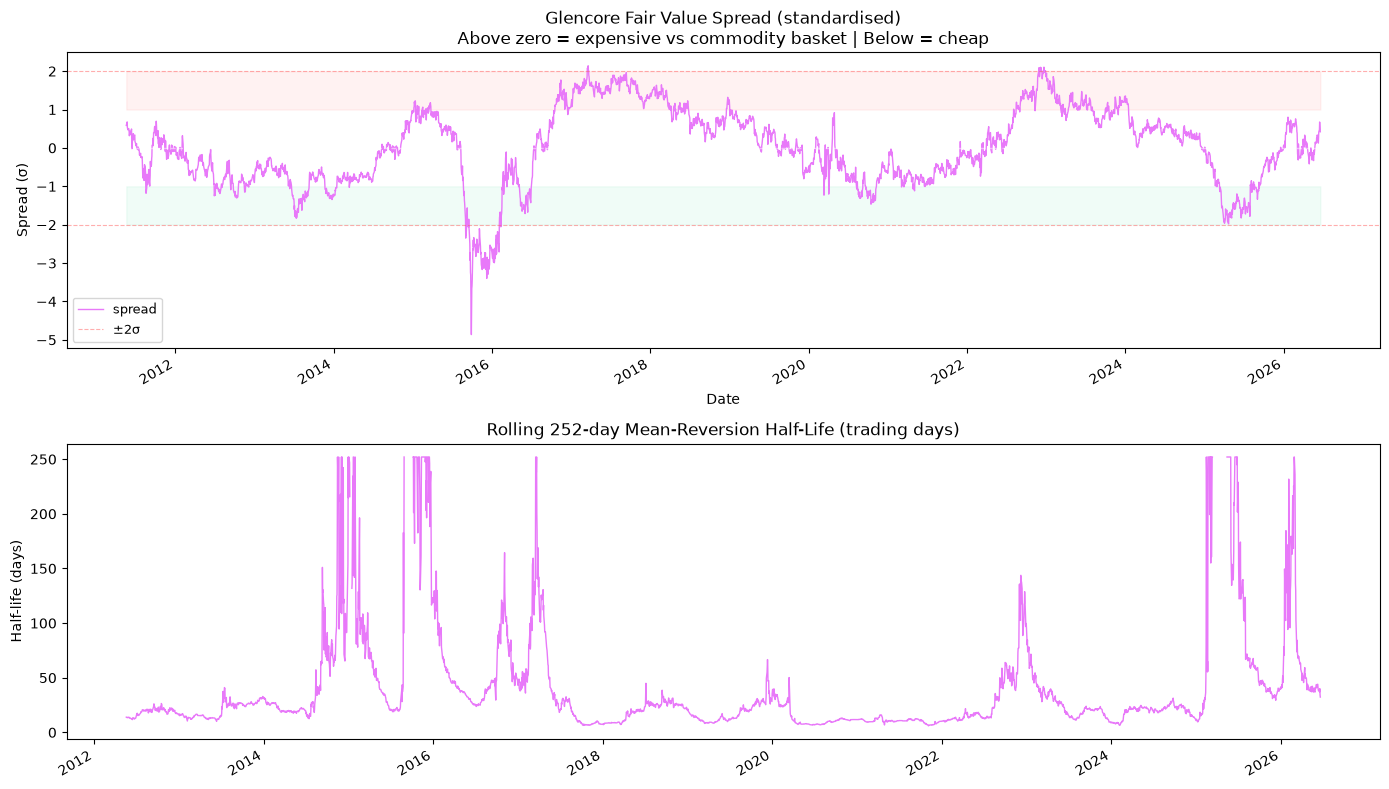

In [7]:
# ── Step 1: Estimate the cointegrating relationship ─────────────────────────
# Regress log(GLEN) on log(Copper) + log(Brent) to get beta coefficients
y = clean_panel["glen"]
X = add_constant(clean_panel[["copper", "brent"]])
ols_res = OLS(y, X).fit()

print("── Cointegrating Regression ────────────────────────────────")
print(f"log(GLEN) = {ols_res.params['const']:.4f}"
      f" + {ols_res.params['copper']:.4f}·log(Copper)"
      f" + {ols_res.params['brent']:.4f}·log(Brent)")
print(f"R² = {ols_res.rsquared:.4f}")

# ── Step 2: Build the spread (residuals from the regression) ────────────────
spread = ols_res.resid
spread.name = "spread"
spread_z = (spread - spread.mean()) / spread.std()  # standardised

# ── Step 3: Confirm spread is stationary (cointegration check) ──────────────
adf_stat, adf_p, *_ = adfuller(spread, autolag="AIC")
print(f"\nSpread ADF test: stat={adf_stat:.4f}, p={adf_p:.6f}")
if adf_p < 0.05:
    print("✓ Spread is stationary — cointegration confirmed")
else:
    print("✗ Spread is non-stationary — cointegration not confirmed")
    print("  Try a different basket or sub-period")

# ── Step 4: Estimate mean-reversion speed via AR(1) ─────────────────────────
spread_lag = spread.shift(1)
delta_spread = spread.diff()
ar1_data = pd.concat([delta_spread, spread_lag], axis=1).dropna()
ar1_data.columns = ["delta_spread", "spread_lag"]

ar1_res = OLS(ar1_data["delta_spread"],
               add_constant(ar1_data["spread_lag"])).fit()
kappa = ar1_res.params["spread_lag"]

if kappa < 0:
    half_life = -np.log(2) / np.log(1 + kappa)
    print(f"\nMean reversion coefficient (κ): {kappa:.4f}")
    print(f"Half-life: {half_life:.1f} trading days ({half_life/21:.1f} months)")
else:
    half_life = None
    print("\n⚠ κ > 0 — spread is explosive, not mean-reverting")

# ── Step 5: Plot the spread ──────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

spread_z.plot(ax=ax1, color="#e879f9", lw=1)
ax1.axhline(0,   color="white",   lw=1,   alpha=0.5, ls="--")
ax1.axhline(2,   color="#ff5f5f", lw=0.8, alpha=0.5, ls="--", label="±2σ")
ax1.axhline(-2,  color="#ff5f5f", lw=0.8, alpha=0.5, ls="--")
ax1.fill_between(spread_z.index,  1, 2,  alpha=0.08, color="#ff5f5f")
ax1.fill_between(spread_z.index, -2, -1, alpha=0.08, color="#4ade9e")
ax1.set_title("Glencore Fair Value Spread (standardised)\n"
              "Above zero = expensive vs commodity basket | Below = cheap")
ax1.set_ylabel("Spread (σ)")
ax1.legend(fontsize=9)

# Rolling 252-day mean-reversion speed
roll_kappa = []
roll_dates = []
for i in range(252, len(spread)):
    w = spread.iloc[i-252:i]
    dd = w.diff().dropna()
    wl = w.shift(1).dropna()
    mn = min(len(dd), len(wl))
    try:
        k = OLS(dd.iloc[:mn], add_constant(wl.iloc[:mn])).fit().params["spread"]
    except:
        k = np.nan
    roll_kappa.append(-np.log(2) / np.log(1 + k) if k is not None and k < 0 else np.nan)
    roll_dates.append(spread.index[i])

roll_hl = pd.Series(roll_kappa, index=roll_dates)
roll_hl.clip(0, 252).plot(ax=ax2, color="#e879f9", lw=1)
ax2.set_title("Rolling 252-day Mean-Reversion Half-Life (trading days)")
ax2.set_ylabel("Half-life (days)")

plt.tight_layout()
plt.savefig("../reports/figures/stage3_spread.png", dpi=150, bbox_inches="tight")
plt.show()

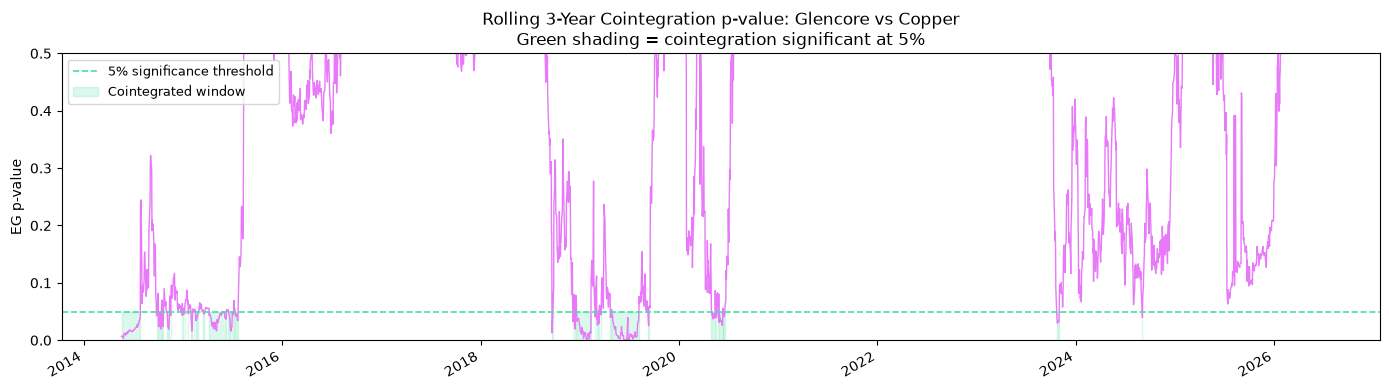

Fraction of rolling windows where cointegration holds: 10.4%


In [8]:
# Rolling 3-year window Engle-Granger p-value for Glencore vs Copper
window = 756  # 3 years of trading days
roll_p = []
roll_dates = []

for i in range(window, len(price_panel)):
    win = price_panel[["glen", "copper"]].iloc[i-window:i].dropna()
    try:
        _, p, _ = coint(win["glen"], win["copper"])
        roll_p.append(p)
    except:
        roll_p.append(np.nan)
    roll_dates.append(price_panel.index[i])

roll_coint = pd.Series(roll_p, index=roll_dates)

fig, ax = plt.subplots(figsize=(14, 4))
roll_coint.plot(ax=ax, color="#e879f9", lw=1)
ax.axhline(0.05, color="#4ade9e", lw=1.2, ls="--",
           label="5% significance threshold")
ax.fill_between(roll_coint.index, 0, 0.05,
                where=roll_coint < 0.05,
                alpha=0.2, color="#4ade9e", label="Cointegrated window")
ax.set_title("Rolling 3-Year Cointegration p-value: Glencore vs Copper\n"
             "Green shading = cointegration significant at 5%")
ax.set_ylabel("EG p-value")
ax.set_ylim(0, 0.5)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("../reports/figures/stage3_rolling_coint.png",
            dpi=150, bbox_inches="tight")
plt.show()

pct_cointegrated = (roll_coint < 0.05).mean() * 100
print(f"Fraction of rolling windows where cointegration holds: {pct_cointegrated:.1f}%")